# Final Dynamic-Graph Model Analysis Hub

This notebook is the single analysis entry point for the two final model families:

1. **Continuous ModernTCN + dynamic graph** — direct continuous Close forecasts.
2. **Tokenized ModernTCN + dynamic graph** — coarse-token prediction, frozen Kronos decode, and ten sampled decoded price paths.

The notebook reads saved artefacts only unless an optional diagnostic section is explicitly enabled. It never retrains a model and it does not touch the held-out test split unless the selected run artefacts themselves were produced on that split.

Graph orientation is always **`A[target, source]`**: rows are receiving assets and columns are influencing assets. Graph heatmaps below display the actual non-negative adjacency weights supplied to message passing—not adjacency minus a uniform graph.

In [4]:
# Cell 1 — imports, project root and evaluation module

from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.evaluation.dynamic_graph_evaluation as dge
from src.utils.metric_tables import DEFAULT_METRIC_DISPLAY_NAMES

dge = importlib.reload(dge)

print("Project root:", project_root)
print("Evaluation module:", dge.__file__)
print("Evaluation module version:", dge.EVALUATION_MODULE_VERSION)

Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis
Evaluation module: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis/src/evaluation/dynamic_graph_evaluation.py
Evaluation module version: 2026-08-04-v9-unified-final-analysis


## 1. Paths and analysis controls

Edit the two run names when a later beta-initialisation run supersedes the current continuous winner. The tokenized policy `selected_temperature` resolves the policy recorded in `temperature_selection.json`.

A **window within date is one-based**: window 1 is the first saved forecast origin on that date.

In [30]:
# Cell 2 — user configuration

FINAL_MODEL_ROOT_CANDIDATES = (
    Path(
        "/Users/vishalruparelia/Library/CloudStorage/"
        "GoogleDrive-vishal@autonomous-fox.ai/"
        "My Drive/dissertation/final_model"
    ),
    Path("/content/drive/MyDrive/dissertation/final_model"),
)
DATA_ROOT_CANDIDATES = (
    Path(
        "/Users/vishalruparelia/Library/CloudStorage/"
        "GoogleDrive-vishal@autonomous-fox.ai/"
        "Shared drives/Vishal/data/cached_datasets/"
        "exp-1m-95s-24y/session"
    ),
    Path(
        "/content/drive/Shareddrives/Vishal/data/cached_datasets/"
        "exp-1m-95s-24y/session"
    ),
)

FINAL_MODEL_ROOT = next(
    (path for path in FINAL_MODEL_ROOT_CANDIDATES if path.is_dir()),
    FINAL_MODEL_ROOT_CANDIDATES[0],
)
DATA_DIR = next(
    (path for path in DATA_ROOT_CANDIDATES if path.is_dir()),
    DATA_ROOT_CANDIDATES[0],
)

CONTINUOUS_RUN_NAME = (
    "mtg_s3_d32_k1_p8s4_lk15_dynamic_g1_h32_"
    "lr0p0001_glr0p0005"
)
TOKEN_RUN_NAME = (
    "token_mtg_d32_k1_p8s4_lk15_dynamic_g1_h32_"
    "lr0p0001_glr0p0005_coarse_ce_select"
)

CONTINUOUS_RUN_DIR = (
    FINAL_MODEL_ROOT / "modern_tcn_graph_sweep" / CONTINUOUS_RUN_NAME
)
TOKEN_RUN_DIR = (
    FINAL_MODEL_ROOT / "tokenized_modern_tcn_final" / TOKEN_RUN_NAME
)
TOKEN_POLICY = "selected_temperature"

TOKEN_DIR = FINAL_MODEL_ROOT / "tokens"
TRAIN_TOKEN_CACHE = TOKEN_DIR / "origin_aligned_train_tokens.pt"
VALIDATION_TOKEN_CACHE = TOKEN_DIR / "origin_aligned_val_tokens.pt"

# Shared graph/forecast example controls.
GRAPH_DATE = "2024-09-03"                 # e.g. "2024-09-03"; None chooses first common date.
GRAPH_WINDOW_WITHIN_DATE = 1      # one-based.
GRAPH_HEAD = "mean"              # "mean" or zero-based graph-head index.
GRAPH_COMPONENT = "selected"     # selected | base | dynamic.
GRAPH_DIRECTION = "impacted_by"  # impacted_by | impacts.
GRAPH_TOP_N = 5
FORECAST_ASSET = "AAPL"

# Probabilistic interval settings.
NOMINAL_COVERAGES = (0.50, 0.80, 0.90)
ASSET_COVERAGE_LEVEL = 0.80

# Optional expensive diagnostics. Saved-artifact sections do not use the GPU.
RUN_TOKEN_DISTRIBUTION = True
RUN_TOKEN_TOPK = True
RUN_GRAPH_RELIANCE = False
RUN_GRAPH_GATE_SWEEP = False
RUN_GRAPH_TOPOLOGY_COUNTERFACTUALS = False
DIAGNOSTIC_MAX_WINDOWS = 64

for label, path in {
    "Continuous run": CONTINUOUS_RUN_DIR,
    "Tokenized run": TOKEN_RUN_DIR,
}.items():
    if not path.is_dir():
        raise FileNotFoundError(f"{label} does not exist: {path}")

print("Final model root:", FINAL_MODEL_ROOT)
print("Raw data:", DATA_DIR)
print("Continuous run:", CONTINUOUS_RUN_DIR)
print("Tokenized run:", TOKEN_RUN_DIR)
print("Tokenized policy:", TOKEN_POLICY)

Final model root: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model
Raw data: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/Shared drives/Vishal/data/cached_datasets/exp-1m-95s-24y/session
Continuous run: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/modern_tcn_graph_sweep/mtg_s3_d32_k1_p8s4_lk15_dynamic_g1_h32_lr0p0001_glr0p0005
Tokenized run: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/final_model/tokenized_modern_tcn_final/token_mtg_d32_k1_p8s4_lk15_dynamic_g1_h32_lr0p0001_glr0p0005_coarse_ce_select
Tokenized policy: selected_temperature


## 2. Saved-artifact audit and run overview

This section validates prediction shapes, horizon labels, asset order, graph orientation, row stochasticity, and policy alignment before any plot is produced. The tokenized row also reports the selected inference temperature and sample count.

In [7]:
# Cell 3 — load and validate both final-model artefact sets

RUNS = {
    "Continuous ModernTCN + dynamic graph": CONTINUOUS_RUN_DIR,
    "Tokenized ModernTCN + dynamic graph": TOKEN_RUN_DIR,
}
POLICIES = {
    "Continuous ModernTCN + dynamic graph": "best",
    "Tokenized ModernTCN + dynamic graph": TOKEN_POLICY,
}

continuous_artifacts = dge.load_analysis_artifacts(
    CONTINUOUS_RUN_DIR,
    policy="best",
)
token_artifacts = dge.load_analysis_artifacts(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
)

run_overview = dge.make_run_overview_table(
    RUNS,
    policies=POLICIES,
)

display(
    run_overview.style
    .format(
        {
            "Spatial beta": "{:.4f}",
            "Dynamic alpha": "{:.4f}",
            "Mean row entropy": "{:.4f}",
            "Mean effective neighbours": "{:.2f}",
            "Temperature": "{:.3f}",
            "Sample count": "{:.0f}",
        },
        na_rep="—",
    )
    .set_caption("Final-model saved-artifact overview")
)

ValueError: Unexpected graph orientation: 'row=target,column=source'.

## 2.1 Frozen architecture summaries

These tables read the exact saved resolved configurations. They do not reconstruct or alter the trained models.

In [9]:
# Cell 3A — exact saved architecture settings

display(
    dge.make_unified_model_summary_table(CONTINUOUS_RUN_DIR)
    .style.set_caption("Continuous final architecture")
)

display(
    dge.make_unified_model_summary_table(TOKEN_RUN_DIR)
    .style.set_caption("Tokenized final architecture")
)

,Value
Field,
Run family,continuous
Run name,mtg_s3_d32_k1_p8s4_lk15_dynamic_g1_h32_lr0p0001_glr0p0005
Assets,93
Evaluation horizons,"[1, 5, 15, 30, 60]"
Selection metric,validation_loss
Input representation,raw
Temporal backbone,modern_tcn
Hidden dimension,32
ModernTCN blocks,1


,Value
Field,
Run family,token
Run name,token_mtg_d32_k1_p8s4_lk15_dynamic_g1_h32_lr0p0001_glr0p0005_coarse_ce_select
Assets,93
Evaluation horizons,"[1, 5, 15, 30, 60]"
Selection metric,validation_token_loss
Token input representation,bsq_bits
Temporal backbone,modern_tcn
Hidden dimension,32
ModernTCN blocks,1


## 3. Complete validation metric comparison

The table reads the exact saved metric table for each displayed policy. For the tokenized model this is the ensemble mean of the ten decoded paths at the selected temperature. No metric is recomputed from another checkpoint.

In [8]:
# Cell 4 — all current evaluator metrics for both final models

FULL_METRIC_ORDER = (
    "cumulative_log_change_mae",
    "cumulative_log_change_median_absolute_error",
    "cumulative_log_change_p95_absolute_error",
    "mase",
    "relative_mae_vs_persistence",
    "persistence_win_rate",
    "cumulative_log_change_pearson_correlation",
    "cumulative_log_change_cross_sectional_pearson_ic",
    "cumulative_log_change_cross_sectional_spearman_rank_ic",
    "cumulative_log_change_movement_magnitude_ratio",
    "cumulative_log_change_temporal_absolute_correlation",
)

full_metrics = dge.make_comparative_metrics_table(
    RUNS,
    policies=POLICIES,
    metrics_to_display=FULL_METRIC_ORDER,
)

display(
    full_metrics.style
    .format(
        {
            "Log MAE": "{:.8f}",
            "Log MedAE": "{:.8f}",
            "Log P95 AE": "{:.8f}",
            "MASE": "{:.5f}",
            "Rel. MAE": "{:.5f}",
            "Win Rate": "{:.6f}",
            "Pearson": "{:.6f}",
            "IC": "{:.6f}",
            "Rank IC": "{:.6f}",
            "MMR": "{:.6f}",
            "AbsRet Corr": "{:.6f}",
        },
        na_rep="—",
    )
    .set_caption("Complete saved validation metrics")
)

ValueError: Unexpected graph orientation: 'row=target,column=source'.

## 4. Training and graph trajectories

The continuous model is selected by validation Log MAE. The tokenized model is selected by validation coarse-token cross-entropy; decoded price-space metrics are diagnostics and temperature calibration occurs only after checkpoint selection.

In [31]:
# Cell 5 — compact history summaries and trajectories

def history_frame(run_dir):
    path = Path(run_dir) / "history.csv"
    if not path.is_file():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def last_finite(frame, column):
    if column not in frame.columns:
        return np.nan
    values = pd.to_numeric(frame[column], errors="coerce").dropna()
    return np.nan if values.empty else float(values.iloc[-1])

continuous_history = history_frame(CONTINUOUS_RUN_DIR)
token_history = history_frame(TOKEN_RUN_DIR)

history_summary = pd.DataFrame(
    [
        {
            "Model": "Continuous",
            "Epochs": len(continuous_history),
            "Best epoch": continuous_artifacts.info.run_metadata.get("best_epoch"),
            "Final spatial beta": last_finite(continuous_history, "spatial_beta"),
            "Final graph entropy": last_finite(
                continuous_history, "graph_mean_row_entropy"
            ),
        },
        {
            "Model": "Tokenized",
            "Epochs": len(token_history),
            "Best epoch": token_artifacts.info.run_metadata.get("best_epoch"),
            "Final spatial beta": last_finite(
                token_history, "validation_spatial_beta"
            ),
            "Final graph entropy": last_finite(
                token_history, "validation_graph_mean_row_entropy"
            ),
        },
    ]
)

display(
    history_summary.style
    .format(
        {
            "Final spatial beta": "{:.4f}",
            "Final graph entropy": "{:.4f}",
        },
        na_rep="—",
    )
    .set_caption("Training-history summary")
)

fig, ax = plt.subplots(figsize=(8.0, 4.5))
if "selection_score" in continuous_history:
    ax.plot(
        continuous_history["epoch"],
        continuous_history["selection_score"],
        label="Continuous validation Log MAE",
    )
if "validation_token_loss" in token_history:
    ax.plot(
        token_history["epoch"],
        token_history["validation_token_loss"],
        label="Tokenized validation coarse-token CE",
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Model-specific selection score")
ax.set_title("Checkpoint-selection trajectories (different scales)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8.0, 4.5))
if "spatial_beta" in continuous_history:
    ax.plot(
        continuous_history["epoch"],
        continuous_history["spatial_beta"],
        label="Continuous beta",
    )
if "validation_spatial_beta" in token_history:
    ax.plot(
        token_history["epoch"],
        token_history["validation_spatial_beta"],
        label="Tokenized beta",
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("Learned spatial beta")
ax.set_title("Temporal-versus-graph feature gate")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

NameError: name 'token_artifacts' is not defined

## 5. Tokenized inference-temperature sweep

Temperature is an inference-only calibration parameter. Each stochastic policy samples ten complete 60-minute coarse-token paths, decodes every path independently, and averages only in raw continuous price space.

In [11]:
# Cell 6 — saved temperature ranking

temperature_results = dge.make_temperature_sweep_table(TOKEN_RUN_DIR)

display(
    temperature_results.style
    .format(
        {
            "Temperature": "{:.3f}",
            "Mean Log MAE": "{:.8f}",
            "Generation seconds": "{:.2f}",
            "Generated s1 accuracy": "{:.6f}",
            "Invalid ensemble candles (%)": "{:.4f}",
            "Invalid sampled-path candles (%)": "{:.4f}",
        },
        na_rep="—",
    )
    .set_caption("Inference-only temperature sweep")
)

,Selected,Policy,Temperature,Sample count,Mean Log MAE,Generation seconds,Generated s1 accuracy,Invalid ensemble candles (%),Invalid sampled-path candles (%),Log MAE — 1 min,Log MAE — 5 min,Log MAE — 15 min,Log MAE — 30 min,Log MAE — 60 min
0,True,temperature_1,1.000,10,0.00153981,2646.57,0.022537,1.0904,24.3371,0.000472,0.000867,0.001484,0.002040,0.002836
1,False,temperature_0p8,0.800,10,0.00154336,2597.93,0.027930,1.9984,23.9600,0.000462,0.000859,0.001486,0.002048,0.002861
2,False,temperature_0p6,0.600,10,0.00156924,2651.47,0.036158,4.2873,23.9556,0.000456,0.000858,0.001504,0.002086,0.002942
3,False,temperature_0p45,0.450,10,0.00161082,2769.26,0.045071,8.1981,24.6845,0.000456,0.000864,0.001531,0.002148,0.003056
4,False,temperature_0p3,0.300,10,0.00167708,3001.01,0.055910,14.0765,25.7659,0.000462,0.000884,0.001579,0.002239,0.003222
5,False,argmax,—,1,0.00186180,287.74,0.066542,24.7859,24.7859,0.000503,0.000982,0.001742,0.002477,0.003605


## 6. Select a date and saved forecast window

The two final models use the same September validation windows. The cell finds dates present in both saved graph artefacts. Set `GRAPH_DATE` in Cell 2 to override the first common date.

In [12]:
# Cell 7 — graph window catalogues and shared selection

continuous_windows = dge.make_graph_window_table(
    CONTINUOUS_RUN_DIR,
    policy="best",
)
token_windows = dge.make_graph_window_table(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
)

common_dates = sorted(
    set(continuous_windows["Date"].dropna())
    & set(token_windows["Date"].dropna())
)
if not common_dates:
    raise RuntimeError("The two runs have no common saved graph dates.")

SELECTED_GRAPH_DATE = (
    common_dates[0] if GRAPH_DATE is None else pd.Timestamp(GRAPH_DATE).date().isoformat()
)
if SELECTED_GRAPH_DATE not in common_dates:
    raise ValueError(
        f"GRAPH_DATE={SELECTED_GRAPH_DATE!r} is not common to both runs. "
        f"Examples: {common_dates[:5]}"
    )

print("Selected graph date:", SELECTED_GRAPH_DATE)
print("Selected one-based window within date:", GRAPH_WINDOW_WITHIN_DATE)

display(
    continuous_windows.loc[
        continuous_windows["Date"] == SELECTED_GRAPH_DATE
    ].style.set_caption("Continuous saved graph windows on selected date")
)

ValueError: Unexpected graph orientation: 'row=target,column=source'.

## 7. Continuous model: exact dynamic adjacency and connections

This is the exact graph saved for the selected validation window. The heatmap shows raw adjacency weights. The connection table uses `A[target, source]`; `impacted_by` lists the strongest source assets for each receiving target.

In [32]:
# Cell 8 — continuous graph snapshot

continuous_snapshot = dge.select_graph_snapshot(
    CONTINUOUS_RUN_DIR,
    policy="best",
    component=GRAPH_COMPONENT,
    head=GRAPH_HEAD,
    date=SELECTED_GRAPH_DATE,
    window_within_date=GRAPH_WINDOW_WITHIN_DATE,
)

continuous_graph_figure, _, continuous_adjacency = dge.plot_graph_snapshot(
    continuous_snapshot,
    cluster=False,
    figsize=(13.0, 11.0),
)
plt.show()

display(
    dge.make_graph_snapshot_summary_table(continuous_snapshot)
    .style
    .format(
        {
            "Mean row entropy": "{:.4f}",
            "Mean effective neighbours": "{:.2f}",
            "Median effective neighbours": "{:.2f}",
            "Maximum edge weight": "{:.6f}",
            "Mean top-5 row mass": "{:.4f}",
        },
        na_rep="—",
    )
    .set_caption("Continuous graph snapshot summary")
)

continuous_connections = dge.make_graph_snapshot_connections_table(
    continuous_snapshot,
    top_n=GRAPH_TOP_N,
    direction=GRAPH_DIRECTION,
)
continuous_weight_columns = [
    column for column in continuous_connections.columns
    if str(column).startswith("Weight")
]
display(
    continuous_connections.style
    .format(
        {column: "{:.6f}" for column in continuous_weight_columns},
        na_rep="—",
    )
    .set_caption("Continuous graph strongest connections")
)

NameError: name 'SELECTED_GRAPH_DATE' is not defined

## 8. Tokenized model: exact dynamic adjacency and connections

The dynamic graph is inferred once from the observed token context and is shared across all ten future sampled paths. This section selects the same date and window as the continuous model.

In [17]:
# Cell 9 — tokenized graph snapshot

token_snapshot = dge.select_graph_snapshot(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
    component=GRAPH_COMPONENT,
    head=GRAPH_HEAD,
    date=SELECTED_GRAPH_DATE,
    window_within_date=GRAPH_WINDOW_WITHIN_DATE,
)

token_graph_figure, _, token_adjacency = dge.plot_graph_snapshot(
    token_snapshot,
    cluster=False,
    figsize=(13.0, 11.0),
)
plt.show()

display(
    dge.make_graph_snapshot_summary_table(token_snapshot)
    .style
    .format(
        {
            "Mean row entropy": "{:.4f}",
            "Mean effective neighbours": "{:.2f}",
            "Median effective neighbours": "{:.2f}",
            "Maximum edge weight": "{:.6f}",
            "Mean top-5 row mass": "{:.4f}",
        },
        na_rep="—",
    )
    .set_caption("Tokenized graph snapshot summary")
)

token_connections = dge.make_graph_snapshot_connections_table(
    token_snapshot,
    top_n=GRAPH_TOP_N,
    direction=GRAPH_DIRECTION,
)
weight_columns = [
    column for column in token_connections.columns
    if str(column).startswith("Weight")
]
display(
    token_connections.style
    .format({column: "{:.6f}" for column in weight_columns}, na_rep="—")
    .set_caption("Tokenized graph strongest connections")
)

NameError: name 'SELECTED_GRAPH_DATE' is not defined

## 9. Continuous-versus-tokenized graph comparison

This comparison is descriptive. Both matrices use the same asset order and the same forecast origin, but the models were trained under different objectives and input representations.

In [18]:
# Cell 10 — same-window adjacency comparison

if tuple(continuous_adjacency.index) != tuple(token_adjacency.index):
    raise AssertionError("Asset order differs between graph snapshots.")

continuous_values = continuous_adjacency.to_numpy(dtype=float)
token_values = token_adjacency.to_numpy(dtype=float)
mask = ~np.eye(len(continuous_adjacency), dtype=bool)
continuous_edges = continuous_values[mask]
token_edges = token_values[mask]

comparison = pd.DataFrame(
    [
        {
            "Date": SELECTED_GRAPH_DATE,
            "Window within date": GRAPH_WINDOW_WITHIN_DATE,
            "Off-diagonal Pearson": pd.Series(continuous_edges).corr(
                pd.Series(token_edges), method="pearson"
            ),
            "Off-diagonal Spearman": pd.Series(continuous_edges).corr(
                pd.Series(token_edges), method="spearman"
            ),
            "Mean absolute edge difference": np.mean(
                np.abs(continuous_edges - token_edges)
            ),
            "Continuous mean entropy": continuous_snapshot.mean_row_entropy,
            "Tokenized mean entropy": token_snapshot.mean_row_entropy,
        }
    ]
)

display(
    comparison.style
    .format(
        {
            "Off-diagonal Pearson": "{:.6f}",
            "Off-diagonal Spearman": "{:.6f}",
            "Mean absolute edge difference": "{:.6f}",
            "Continuous mean entropy": "{:.4f}",
            "Tokenized mean entropy": "{:.4f}",
        }
    )
    .set_caption("Same-window graph comparison")
)

NameError: name 'continuous_adjacency' is not defined

## 10. Point forecasts for the selected asset/window

The continuous plot displays its five direct predictions. The tokenized plot displays the ensemble-mean predictions saved by the selected temperature policy.

In [19]:
# Cell 11 — selected point forecasts

if FORECAST_ASSET not in continuous_artifacts.info.asset_cols:
    FORECAST_ASSET = continuous_artifacts.info.asset_cols[0]
    print("Requested asset unavailable; using", FORECAST_ASSET)

fig, _, continuous_point_table = dge.plot_point_forecast_window(
    CONTINUOUS_RUN_DIR,
    policy="best",
    asset=FORECAST_ASSET,
    date=SELECTED_GRAPH_DATE,
    window_within_date=GRAPH_WINDOW_WITHIN_DATE,
)
plt.show()
display(continuous_point_table.style.format("{:.6f}"))

fig, _, token_point_table = dge.plot_point_forecast_window(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
    asset=FORECAST_ASSET,
    date=SELECTED_GRAPH_DATE,
    window_within_date=GRAPH_WINDOW_WITHIN_DATE,
)
plt.show()
display(token_point_table.style.format("{:.6f}"))

NameError: name 'SELECTED_GRAPH_DATE' is not defined

## 11. All ten sampled decoded price paths

The plot shows every saved decoded path, the ensemble mean, the observed context, and the full realised 60-minute future Close path reconstructed from the canonical validation data. Nothing is resampled in this notebook.

In [20]:
# Cell 12 — sampled paths, ensemble mean and true future

sampled_path_figure, _, sampled_path_table = dge.plot_sampled_price_paths(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
    asset=FORECAST_ASSET,
    date=SELECTED_GRAPH_DATE,
    window_within_date=GRAPH_WINDOW_WITHIN_DATE,
    data_dir=DATA_DIR,
    split="validation",
    context_points=30,
    figsize=(12.0, 6.0),
)
plt.show()

display(
    sampled_path_table.loc[
        sampled_path_table.index.isin([1, 5, 15, 30, 60])
    ].style.format("{:.6f}").set_caption(
        "Saved sampled paths at reported horizons"
    )
)

NameError: name 'SELECTED_GRAPH_DATE' is not defined

## 12. Predictive interval coverage

Intervals are central empirical quantile intervals in **cumulative log-return space**. Coverage is pooled across validation windows and assets at each horizon. Widths are reported in log-return basis points, avoiding raw-price scale distortions.

With only ten paths, the interval grid is necessarily coarse; the results are diagnostics of the finite ensemble rather than asymptotic confidence intervals.

In [21]:
# Cell 13 — horizon-level coverage and calibration plot

coverage_table = dge.make_predictive_coverage_table(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
    nominal_coverages=NOMINAL_COVERAGES,
    include_sample_range=True,
)

display(
    coverage_table.style
    .format(
        {
            "Temperature": "{:.3f}",
            "Nominal coverage": "{:.3f}",
            "Empirical coverage": "{:.3f}",
            "Coverage gap": "{:+.3f}",
            "Below interval": "{:.3f}",
            "Above interval": "{:.3f}",
            "Mean interval width (log-return bps)": "{:.3f}",
            "Median interval width (log-return bps)": "{:.3f}",
        },
        na_rep="—",
    )
    .set_caption("Finite-ensemble predictive interval coverage")
)

coverage_figure, _ = dge.plot_coverage_calibration(coverage_table)
plt.show()

ValueError: Unexpected graph orientation: 'row=target,column=source'.

### 12.1 Coverage by asset

This table identifies assets whose predictive intervals are systematically too narrow or too wide. It is useful for selecting examples for the dissertation, but it is not used for model or temperature selection.

In [22]:
# Cell 14 — asset/horizon coverage table and calibration ranking

asset_coverage = dge.make_predictive_coverage_by_asset_table(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
    nominal_coverage=ASSET_COVERAGE_LEVEL,
)
asset_coverage["Absolute coverage gap"] = (
    asset_coverage["Empirical coverage"] - ASSET_COVERAGE_LEVEL
).abs()

asset_calibration_summary = (
    asset_coverage.groupby("Asset", as_index=False)
    .agg(
        Mean_empirical_coverage=("Empirical coverage", "mean"),
        Mean_absolute_coverage_gap=("Absolute coverage gap", "mean"),
        Mean_interval_width_bps=(
            "Mean interval width (log-return bps)", "mean"
        ),
    )
    .sort_values("Mean_absolute_coverage_gap")
)

display(
    asset_calibration_summary.style
    .format(
        {
            "Mean_empirical_coverage": "{:.3f}",
            "Mean_absolute_coverage_gap": "{:.3f}",
            "Mean_interval_width_bps": "{:.3f}",
        }
    )
    .set_caption(
        f"Asset-level calibration summary for central "
        f"{100*ASSET_COVERAGE_LEVEL:g}% intervals"
    )
)

ValueError: Unexpected graph orientation: 'row=target,column=source'.

## 13. Probabilistic scores and finite-ensemble rank diagnostics

Empirical CRPS evaluates the entire sampled cumulative-return distribution. The rank table counts how many of the ten sampled returns fall below the realised return; a calibrated continuous distribution would be approximately uniform over ranks 0–10.

In [23]:
# Cell 15 — CRPS, sample dispersion and rank histogram table

probabilistic_scores = dge.make_probabilistic_score_table(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
)

display(
    probabilistic_scores.style
    .format(
        {
            "Temperature": "{:.3f}",
            "Empirical CRPS (log-return bps)": "{:.4f}",
            "Ensemble-mean Log MAE": "{:.8f}",
            "Sample-median Log MAE": "{:.8f}",
            "Mean predictive std (log-return bps)": "{:.4f}",
            "Median predictive std (log-return bps)": "{:.4f}",
        }
    )
    .set_caption("Probabilistic forecast scores")
)

rank_table = dge.make_sample_rank_histogram_table(
    TOKEN_RUN_DIR,
    policy=TOKEN_POLICY,
)

display(
    rank_table.pivot(
        index="Rank",
        columns="Horizon",
        values="Frequency",
    )
    .style
    .format("{:.4f}")
    .set_caption("Truth rank among ten sampled paths")
)

ValueError: Unexpected graph orientation: 'row=target,column=source'.

## 14. Coarse-token predictive distribution *(optional, model forward pass)*

This retains the original Graph Hub diagnostic. It analyses the selected token checkpoint’s free-running `s1` distributions and compares hard-predicted token use with the training target distribution. It does not decode prices.

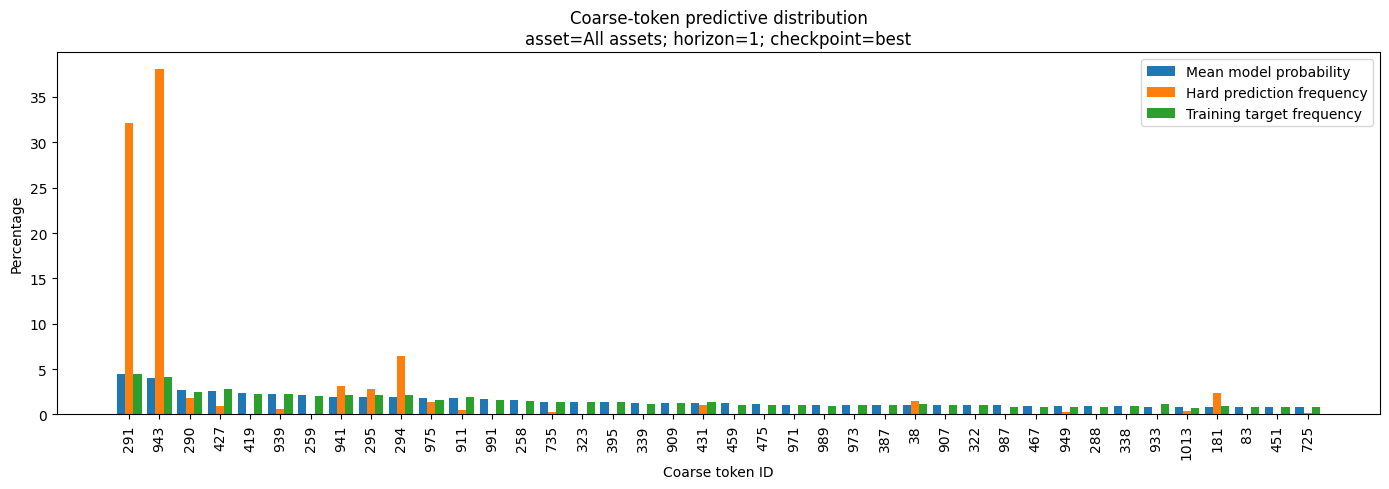

ValueError: Unknown format code 'f' for object of type 'str'

,Token ID,Predicted Count,Predicted Frequency (%),Mean Predictive Probability (%),Training Target Count,Training Target Frequency (%)
0,943.000000,2264.000000,38.037634,4.050520,12331.000000,4.178739
1,291.000000,1915.000000,32.174059,4.422517,13196.000000,4.471871
2,294.000000,386.000000,6.485215,1.876370,6302.000000,2.135627
3,941.000000,184.000000,3.091398,1.914730,6288.000000,2.130883
4,295.000000,170.000000,2.856183,1.897011,6256.000000,2.120038
5,181.000000,141.000000,2.368952,0.828747,2653.000000,0.899051
6,37.000000,117.000000,1.965726,0.597892,2346.000000,0.795014
7,290.000000,105.000000,1.764113,2.752252,7430.000000,2.517884
8,38.000000,90.000000,1.512097,1.050340,3331.000000,1.128812
9,46.000000,89.000000,1.495296,0.615211,3008.000000,1.019353


In [28]:
# Cell 16 — optional coarse-token predictive distribution

if RUN_TOKEN_DISTRIBUTION:
    token_distribution = dge.analyse_token_predictive_distribution(
        TOKEN_RUN_DIR,
        asset=None,
        horizon=1,
        source="best",
        validation_cache_path=VALIDATION_TOKEN_CACHE,
        training_cache_path=TRAIN_TOKEN_CACHE,
        window_indices=None,
        max_windows=DIAGNOSTIC_MAX_WINDOWS,
        batch_size=2,
        device=None,
        use_amp=None,
        plot_top_n=40,
        figsize=(14.0, 5.0),
    )
    display(token_distribution["figure"])
    display(
        token_distribution["summary"].style
        .format("{:.6f}", na_rep="—")
        .set_caption("Coarse-token predictive-distribution summary")
    )
    display(
        token_distribution["token_table"].style
        .format("{:.6f}", na_rep="—")
        .set_caption("Predicted coarse-token use and training frequency")
    )
else:
    print("Skipped. Set RUN_TOKEN_DISTRIBUTION=True in Cell 2 to run it.")

## 15. Coarse-token top-k accuracy by future horizon *(optional, model forward pass)*

Top-k accuracy asks whether the realised future coarse token lies among the model’s highest-probability candidates. The table also retains the training-marginal comparison stored in its attributes.

In [29]:
# Cell 17 — optional free-running s1 top-k accuracy

if RUN_TOKEN_TOPK:
    s1_topk_accuracy = dge.analyse_s1_topk_accuracy_by_horizon(
        TOKEN_RUN_DIR,
        asset=None,
        source="best",
        validation_cache_path=VALIDATION_TOKEN_CACHE,
        window_indices=None,
        max_windows=DIAGNOSTIC_MAX_WINDOWS,
        batch_size=2,
        device=None,
        use_amp=None,
        top_k_values=(1, 2, 5, 10),
        horizons=(1, 5, 15, 30, 60),
    )
    display(
        s1_topk_accuracy.style
        .format("{:.3f}")
        .set_caption("Free-running coarse-token top-k accuracy")
    )
else:
    print("Skipped. Set RUN_TOKEN_TOPK=True in Cell 2 to run it.")

## 16. Spatial-branch and topology interventions *(optional, expensive)*

These original Graph Hub diagnostics reconstruct the tokenized model and validation cache. They are useful for checking whether the model uses the graph branch and the learned topology, but they are not required for the saved-artifact analysis above.

In [ ]:
# Cell 18 — optional branch-scale diagnostic

if RUN_GRAPH_RELIANCE:
    branch_diagnostics = dge.analyse_spatial_branch_reliance(
        TOKEN_RUN_DIR,
        source="best",
        validation_cache_path=VALIDATION_TOKEN_CACHE,
        window_indices=None,
        max_windows=DIAGNOSTIC_MAX_WINDOWS,
        batch_size=2,
        device=None,
        use_amp=None,
        block_index=0,
        spatial_layer_index=0,
    )
    display(
        branch_diagnostics.summary.style
        .format("{:.6f}", na_rep="—")
        .set_caption("Temporal residual versus graph-message branch")
    )
    display(
        branch_diagnostics.per_asset
        .sort_values("Graph / temporal scale ratio", ascending=False)
        .style.format("{:.6f}", na_rep="—")
        .set_caption("Spatial-branch influence by asset")
    )
else:
    print("Skipped. Set RUN_GRAPH_RELIANCE=True in Cell 2 to run it.")

In [ ]:
# Cell 19 — optional graph-message gate sweep

if RUN_GRAPH_GATE_SWEEP:
    gate_diagnostics = dge.analyse_graph_gate_sweep(
        TOKEN_RUN_DIR,
        source="best",
        gammas=(0.0, 0.25, 0.50, 0.75, 1.0),
        validation_cache_path=VALIDATION_TOKEN_CACHE,
        forecasting_config_path=None,
        window_indices=None,
        max_windows=DIAGNOSTIC_MAX_WINDOWS,
        batch_size=1,
        device=None,
        use_amp=None,
        block_index=0,
        spatial_layer_index=0,
        decode=False,
        decode_series_batch_size=64,
    )
    display(
        gate_diagnostics.summary.style
        .format("{:.6f}", na_rep="—")
        .set_caption("Graph-message gate sweep")
    )
    figure, _ = dge.plot_graph_gate_sweep(
        gate_diagnostics,
        metric="s1 argmax change vs actual",
    )
    plt.show()
else:
    print("Skipped. Set RUN_GRAPH_GATE_SWEEP=True in Cell 2 to run it.")

In [ ]:
# Cell 20 — optional graph-topology counterfactuals

if RUN_GRAPH_TOPOLOGY_COUNTERFACTUALS:
    topology_diagnostics = dge.analyse_graph_topology_counterfactuals(
        TOKEN_RUN_DIR,
        source="best",
        interventions=("actual", "zero_message", "uniform", "shuffled"),
        validation_cache_path=VALIDATION_TOKEN_CACHE,
        forecasting_config_path=None,
        window_indices=None,
        max_windows=DIAGNOSTIC_MAX_WINDOWS,
        batch_size=2,
        device=None,
        use_amp=None,
        block_index=0,
        spatial_layer_index=0,
        decode=False,
        decode_series_batch_size=64,
        shuffle_seed=42,
    )
    display(
        topology_diagnostics.summary.style
        .format("{:.6f}", na_rep="—")
        .set_caption("Graph-topology counterfactuals")
    )
    display(
        topology_diagnostics.per_horizon.style
        .format("{:.6f}", na_rep="—")
        .set_caption("Graph-topology counterfactuals by horizon")
    )
else:
    print(
        "Skipped. Set RUN_GRAPH_TOPOLOGY_COUNTERFACTUALS=True in Cell 2 "
        "to run it."
    )

## 17. Write-up checklist

Read the outputs jointly:

- **Forecast error:** mean, median and tail Log MAE by horizon.
- **Directional/ranking signal:** Pearson, IC and Rank IC.
- **Graph use:** learned spatial beta and optional intervention sensitivity.
- **Graph structure:** exact same-window adjacency, entropy, effective neighbours and strongest directed connections.
- **Probabilistic calibration:** interval coverage, interval width, CRPS, predictive dispersion and rank histograms.
- **Tokenizer diagnosis:** token entropy, hard-prediction vocabulary and top-k accuracy.

Do not treat a graph heatmap as causal evidence. The learned adjacency is the routing matrix used by the model; its interpretation should be supported by predictive ablations, topology interventions and stability across windows.